# Exploratory Data Analysis (EDA): Credit Card Fraud Detection

**Objective:** To identify emerging fraud trends and anomalous transaction patterns, validate initial risk metrics, and establish a data-driven foundation for advanced fraud prevention strategies.

**EDA Phases:**
1. **Data Ingestion & Data Profiling:** Validating historical data quality, assessing schema integrity, and identifying missing values or data anomalies.
2. **Target Variable Analysis:** Evaluating the baseline fraud rate and analyzing the class imbalance characteristics.
3. **Behavioral Analysis:** Investigating spending anomalies based on transaction distributions and merchant categories.
4. **Temporal Analysis:** Detecting fraudulent operation patterns across temporal dimensions (e.g., specific hours and days of the week).
5. **Geospatial & Demographic Profiling:** Analyzing spatial anomalies (customer-to-merchant distance) and victim demographics to enhance rule-based detection.
6. **Feature Correlation:** Examining multicollinearity among continuous variables to prepare the dataset for predictive modeling.

## 1. Data Ingestion & Data Profiling
The purpose of this stage is to load raw data and perform an initial *sanity check* to understand the dataset specifications (data types, missing or empty values, duplicates, and feature cardinality).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid", palette="muted")

# 1. Data Ingestion
train_path = '../dataset/01_raw/fraudTrain.csv'
df_train = pd.read_csv(train_path)

# Drop index bawaan dari CSV (jika ada)
if 'Unnamed: 0' in df_train.columns:
    df_train = df_train.drop(columns=['Unnamed: 0'])

print(f"Dataset Shape: {df_train.shape[0]:,} baris dan {df_train.shape[1]} kolom")
display(df_train.head())

Dataset Shape: 1,296,675 baris dan 22 kolom


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


### 1.1 Dataset Specifications (Data Types, Missing Values, & Cardinality)
Create a summary of the data profile to determine whether any columns require data *cleaning* or imputation, and to assess the number of unique values (cardinality) in order to determine the *encoding* strategy later on.

In [4]:
# Membuat Dataframe Profiling
data_profiling = pd.DataFrame({
    'Data Type': df_train.dtypes,
    'Missing Values': df_train.isnull().sum(),
    'Missing %': (df_train.isnull().sum() / len(df_train)) * 100,
    'Unique Values': df_train.nunique()
})

# Tampilkan metrik kebersihan data
print(f"Total Baris Duplikat: {df_train.duplicated().sum()}")
display(data_profiling.style.background_gradient(cmap='Reds', subset=['Missing %']))

Total Baris Duplikat: 0


,Data Type,Missing Values,Missing %,Unique Values
trans_date_trans_time,object,0,0.000000,1274791
cc_num,int64,0,0.000000,983
merchant,object,0,0.000000,693
category,object,0,0.000000,14
amt,float64,0,0.000000,52928
first,object,0,0.000000,352
last,object,0,0.000000,481
gender,object,0,0.000000,2
street,object,0,0.000000,983
city,object,0,0.000000,894


### 1.2 Summary of Basic Statistics
Check the initial distribution of numerical and categorical features. This is useful for detecting *outliers* (extreme values) in numerical data (such as `amt`) and identifying the most common categories in categorical data.

In [5]:
# Ringkasan Statistik Data Numerik
print("Statistik Deskriptif (Numerik)")
# Membuang sementara kolom yang secara teknis numerik tapi bersifat ID/kategorikal
num_cols_to_exclude = ['cc_num', 'is_fraud', 'zip', 'unix_time']
num_cols = [col for col in df_train.select_dtypes(include=['int64', 'float64']).columns if col not in num_cols_to_exclude]

display(df_train[num_cols].describe().apply(lambda s: s.apply('{0:.2f}'.format)))

print("\nStatistik Deskriptif (Kategorikal)")
# Menampilkan deskripsi data objek/kategorikal
display(df_train.select_dtypes(include=['object']).describe())

Statistik Deskriptif (Numerik)


,amt,lat,long,city_pop,merch_lat,merch_long
count,1296675.00,1296675.00,1296675.00,1296675.00,1296675.00,1296675.00
mean,70.35,38.54,-90.23,88824.44,38.54,-90.23
std,160.32,5.08,13.76,301956.36,5.11,13.77
min,1.00,20.03,-165.67,23.00,19.03,-166.67
25%,9.65,34.62,-96.80,743.00,34.73,-96.90
50%,47.52,39.35,-87.48,2456.00,39.37,-87.44
75%,83.14,41.94,-80.16,20328.00,41.96,-80.24
max,28948.90,66.69,-67.95,2906700.00,67.51,-66.95



Statistik Deskriptif (Kategorikal)


,trans_date_trans_time,merchant,category,first,last,gender,street,city,state,job,dob,trans_num
count,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675
unique,1274791,693,14,352,481,2,983,894,51,494,968,1296675
top,2019-04-22 16:02:01,fraud_Kilback LLC,gas_transport,Christopher,Smith,F,864 Reynolds Plains,Birmingham,TX,Film/video editor,1977-03-23,8f7c8e4ab7f25875d753b422917c98c9
freq,4,4403,131659,26669,28794,709863,3123,5617,94876,9779,5636,1


## 2. Target Variable Analysis (Class Imbalance)
Examine the distribution of the target variable (`is_fraud`). Fraud detection almost always involves class imbalance (imbalanced data), which will determine our model’s evaluation metrics later on.

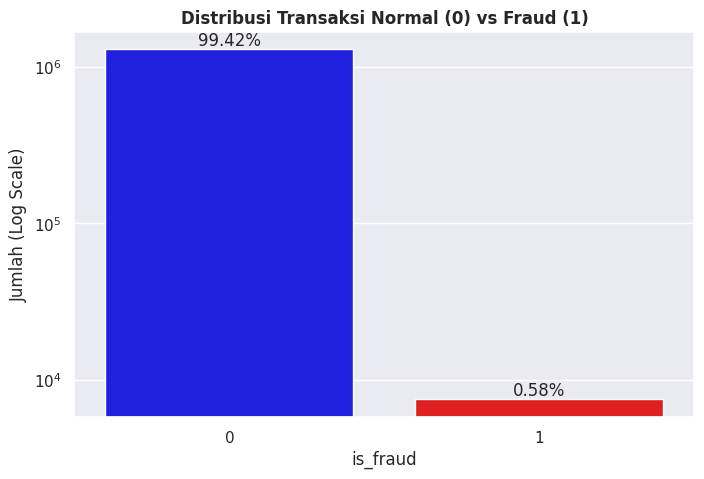

In [9]:
# 2. Distribusi Kelas Target
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='is_fraud', data=df_train, palette=['blue', 'red'])

# Menambahkan persentase di atas bar
total = len(df_train)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.title('Distribusi Transaksi Normal (0) vs Fraud (1)', fontweight='bold')
plt.yscale('log') # Log scale karena perbedaan jumlah sangat jauh
plt.ylabel('Jumlah (Log Scale)')
plt.show()

## 3. Behavioral Exploration: Amount vs. Fraud
Examining whether there are differences in behavior (*behavior*) in terms of transaction value (`amt`) between normal transactions and *fraud*.

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1289169.00,67.67,154.01,1.00,9.61,47.28,82.54,28948.90
1,7506.00,531.32,390.56,1.06,245.66,396.50,900.88,1376.04


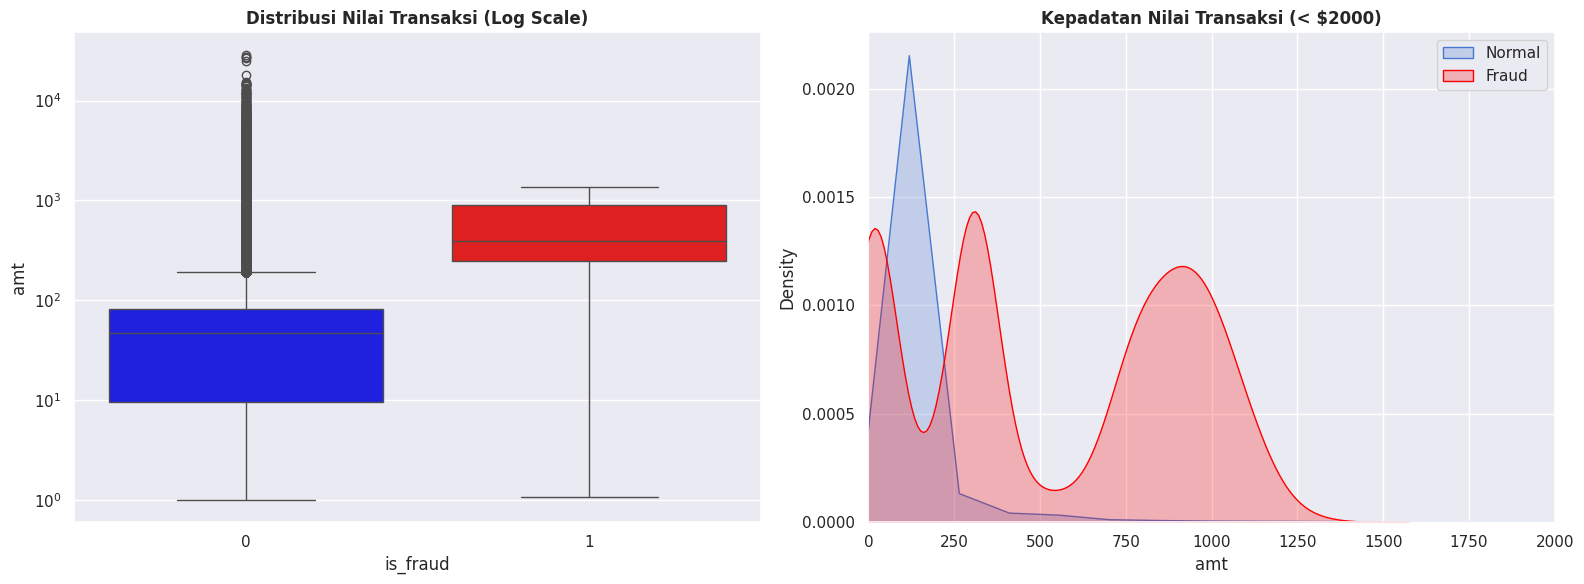

In [10]:
# 3. Analisis Nilai Transaksi
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
sns.boxplot(x='is_fraud', y='amt', data=df_train, ax=ax[0], palette=['blue', 'red'])
ax[0].set_yscale('log')
ax[0].set_title('Distribusi Nilai Transaksi (Log Scale)', fontweight='bold')

# Metrik Statistik Deskriptif untuk nilai transaksi Fraud vs Normal
desc_amt = df_train.groupby('is_fraud')['amt'].describe()
display(desc_amt.apply(lambda s: s.apply('{0:.2f}'.format)))

# Distribusi Kepadatan (KDE)
sns.kdeplot(df_train[df_train['is_fraud']==0]['amt'], label='Normal', shade=True, ax=ax[1])
sns.kdeplot(df_train[df_train['is_fraud']==1]['amt'], label='Fraud', shade=True, ax=ax[1], color='red')
ax[1].set_xlim(0, 2000) # Membatasi x-axis agar lebih jelas
ax[1].set_title('Kepadatan Nilai Transaksi (< $2000)', fontweight='bold')
ax[1].legend()

plt.tight_layout()
plt.show()

## 4. Temporal & Categorical Exploration
*Fraudsters* often operate within specific *merchant* categories and at specific times. We will perform temporal feature extraction (for EDA visualization only).

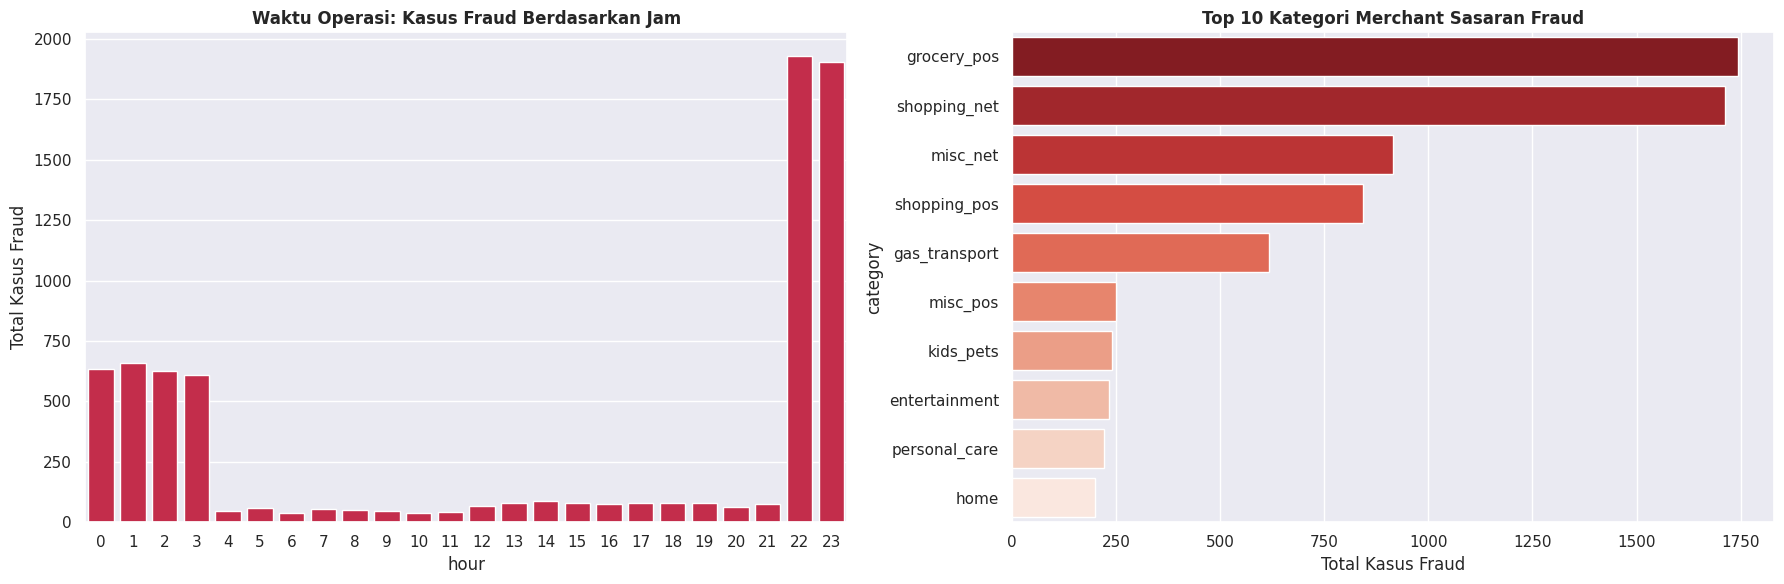

In [11]:
# Ekstraksi sementara untuk EDA
df_train['trans_date_trans_time'] = pd.to_datetime(df_train['trans_date_trans_time'])
df_train['hour'] = df_train['trans_date_trans_time'].dt.hour

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Pola Fraud berdasarkan Jam
fraud_by_hour = df_train[df_train['is_fraud'] == 1].groupby('hour').size()
sns.barplot(x=fraud_by_hour.index, y=fraud_by_hour.values, ax=ax[0], color='crimson')
ax[0].set_title('Waktu Operasi: Kasus Fraud Berdasarkan Jam', fontweight='bold')
ax[0].set_ylabel('Total Kasus Fraud')

# Pola Fraud berdasarkan Kategori Merchant
fraud_by_category = df_train[df_train['is_fraud'] == 1]['category'].value_counts().head(10)
sns.barplot(y=fraud_by_category.index, x=fraud_by_category.values, ax=ax[1], palette='Reds_r')
ax[1].set_title('Top 10 Kategori Merchant Sasaran Fraud', fontweight='bold')
ax[1].set_xlabel('Total Kasus Fraud')

plt.tight_layout()
plt.show()

## 5. Correlation Analysis
The final step in EDA is to examine the linear relationships among the original numerical variables in the dataset.

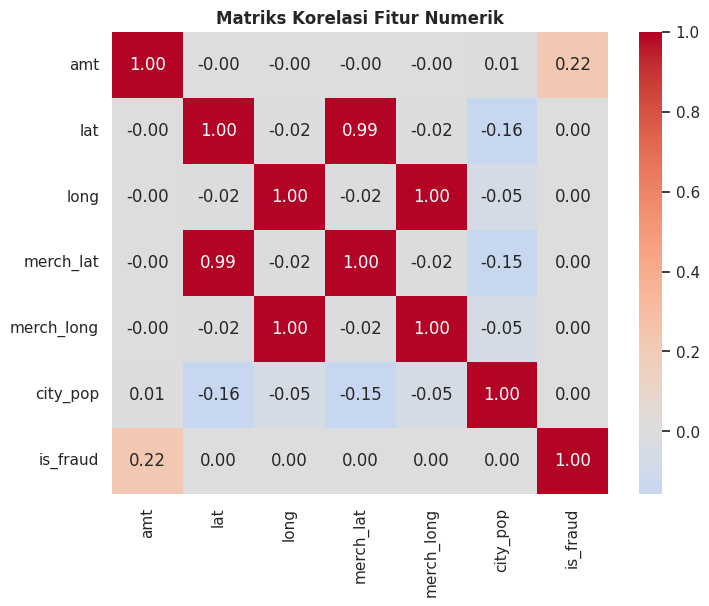

In [12]:
# 5. Matriks Korelasi (Hanya untuk numerik bawaan)
features_to_correlate = ['amt', 'lat', 'long', 'merch_lat', 'merch_long', 'city_pop', 'is_fraud']
corr_matrix = df_train[features_to_correlate].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title('Matriks Korelasi Fitur Numerik', fontweight='bold')
plt.show()

## 6. Risk Profiling
Analyzing behavioral anomalies based on the physical (geospatial) distance between customers and *merchants*, as well as the demographic profile (age) of cardholders, to strengthen the detection rules (*rules engine*).

In [15]:
import math

# 1. Fungsi untuk menghitung jarak Haversine (dalam kilometer)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0 # Radius bumi dalam km
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat / 2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c

# 2. Eksekusi perhitungan jarak (Customer ke Merchant)
df_train['distance_km'] = df_train.apply(
    lambda row: haversine(row['lat'], row['long'], row['merch_lat'], row['merch_long']), 
    axis=1
)

# 3. Eksekusi perhitungan umur
df_train['dob'] = pd.to_datetime(df_train['dob'])
df_train['trans_date_trans_time'] = pd.to_datetime(df_train['trans_date_trans_time'])
df_train['age'] = (df_train['trans_date_trans_time'] - df_train['dob']).dt.days // 365

print(f"Kolom berhasil ditambahkan! Total kolom sekarang: {df_train.shape[1]}")

Kolom berhasil ditambahkan! Total kolom sekarang: 27


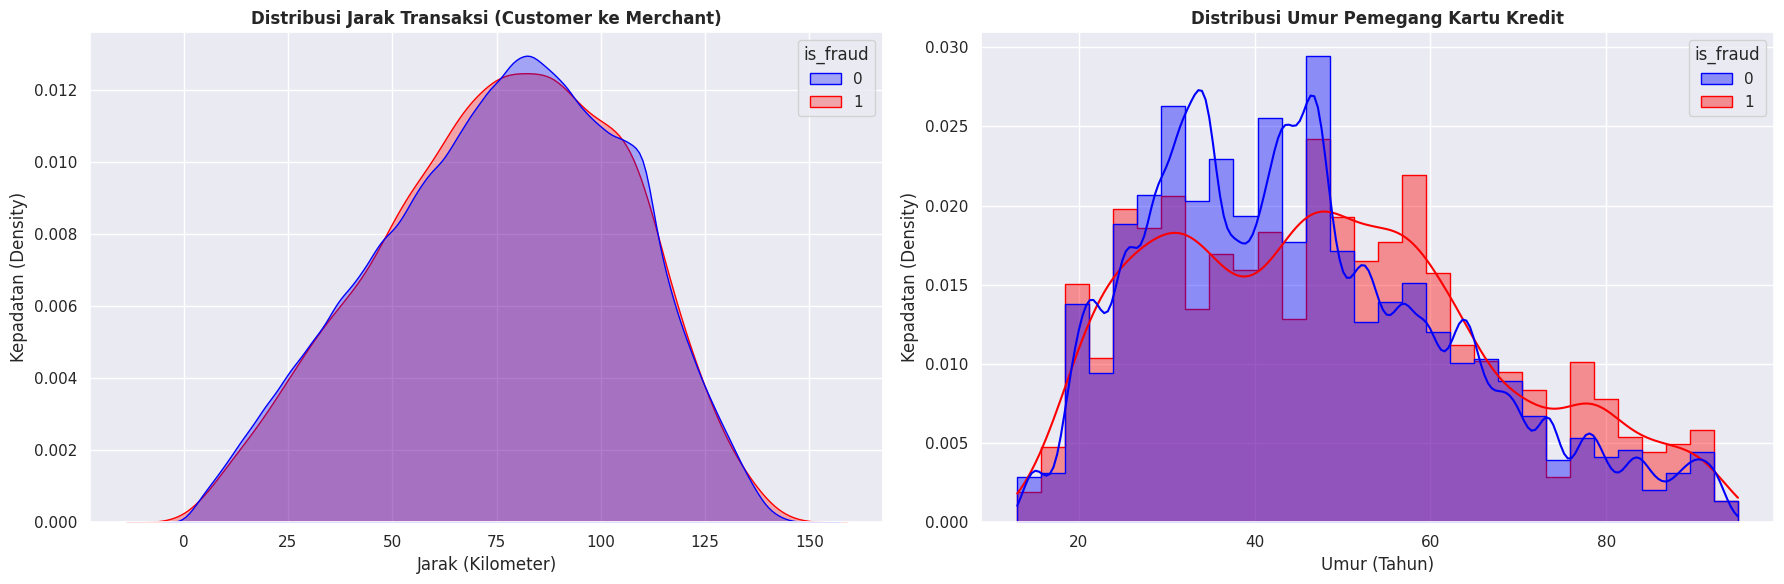

Ringkasan Jarak (KM)


,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1289169.00,76.11,29.12,0.02,55.33,78.23,98.50,152.12
1,7506.00,76.27,28.75,0.74,55.63,77.93,98.39,144.52



Ringkasan Umur (Tahun)


,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1289169.00,45.51,17.40,13.00,32.00,43.00,57.00,95.00
1,7506.00,48.32,18.86,14.00,33.00,47.00,60.00,93.00


In [17]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Analisis Jarak Transaksi
sns.kdeplot(
    data=df_train, x='distance_km', hue='is_fraud', 
    fill=True, palette=['blue', 'red'], alpha=0.3, 
    common_norm=False, ax=ax[0]
)
# Opsional: Jika jarak menumpuk di kiri, Anda bisa membatasi axis atau menggunakan log scale
# ax[0].set_xlim(0, 200) 
ax[0].set_title('Distribusi Jarak Transaksi (Customer ke Merchant)', fontweight='bold')
ax[0].set_xlabel('Jarak (Kilometer)')
ax[0].set_ylabel('Kepadatan (Density)')

# Analisis Umur Korban
sns.histplot(
    data=df_train, x='age', hue='is_fraud', bins=30, 
    stat="density", element="step", common_norm=False, 
    palette=['blue', 'red'], alpha=0.4, kde=True, ax=ax[1]
)
ax[1].set_title('Distribusi Umur Pemegang Kartu Kredit', fontweight='bold')
ax[1].set_xlabel('Umur (Tahun)')
ax[1].set_ylabel('Kepadatan (Density)')

plt.tight_layout()
plt.show()

# Menampilkan perbandingan ringkasan statistik tanpa scientific notation
print("Ringkasan Jarak (KM)")
display(df_train.groupby('is_fraud')['distance_km'].describe().apply(lambda s: s.apply('{0:.2f}'.format)))

print("\nRingkasan Umur (Tahun)")
display(df_train.groupby('is_fraud')['age'].describe().apply(lambda s: s.apply('{0:.2f}'.format)))